## Image registration

The notebook uses a python package itk-elastix (https://proceedings.scipy.org/articles/gerudo-f2bc6f59-00d) to demonstrate image registration in a few image examples. 

Source of the images:

A Multi-Stain Breast Cancer Histological Whole-Slide-Image Data Set from Routine Diagnostics

The pair of images from histology represent a breast cancer section with H&E and IHC staining for PGR. It is extracted at 10X resolution level from within the dataset published at:

A Multi-Stain Breast Cancer Histological Whole-Slide-Image Data Set from Routine Diagnostics
by Weitz, Valkonen, Solorzano et al
Scientific Data
https://www.nature.com/articles/s41597-023-02422-6

This dataset provides the largest publicly available collection of Breast Cancer whole slide images (WSIs) from 1,153 breast cancer patients, including matched H&E and IHC-stained sections (4,212 WSIs) for ER, PGR, HER2, and Ki67. It enables AI-driven analysis of IHC stains, supporting automated scoring, heterogeneity studies, and improved prognostic modeling by offering paired, high-quality imaging data for computational pathology research.

In breast cancer, PGR (Progesterone Receptor) IHC staining typically shows nuclear positivity, with PGR+ (≥1-10% cells, Allred ≥3) associated with better prognosis and endocrine therapy responsiveness, while PGR- may indicate more aggressive disease. PGR status aids in breast cancer subtyping and treatment guidance.


In [1]:
from pathlib import Path

import itk
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from registration_utils import (
    read_grayscale,
    read_rgb,
    pad_to_common_size,
    pad_to_shape,
    rgb_channel_to_padded_image,
    shift_image,
    checkerboard,
    magenta_cyan_overlay,
)

`read_grayscale`, `read_rgb`, `pad_to_common_size`, `pad_to_shape`, `rgb_channel_to_padded_image`, `shift_image`, `checkerboard` and `magenta_cyan_overlay` are plumbing, not registration logic, so they live in [`registration_utils.py`](registration_utils.py) next to this notebook — open it if you want to see how they work.

### Reading the files

Both images are RGB. Convert each to single-channel grayscale explicitly with `skimage.color.rgb2gray` (standard Rec. 709 luma weights) before doing anything else, since the registration metrics below expect scalar images.

In [2]:
data_dir = Path("/home/leslie/Documents/NBIS/I2K")

fixed_image = read_grayscale(data_dir / "18_HE_val_level3.jpg")
moving_image = read_grayscale(data_dir / "18_PGR_val_level3.jpg")

### Matching image sizes

Registration and the overlay visualizations below assume the fixed and moving images have the same pixel dimensions. If they don't, embed both into zero-filled canvases sized to the largest extent in each dimension (i.e. place each image on top of a blank canvas at the origin) before doing anything else with them.

In [3]:
fixed_image, moving_image = pad_to_common_size(fixed_image, moving_image)
print("Fixed image size:", itk.size(fixed_image))
print("Moving image size:", itk.size(moving_image))

Fixed image size: itkSize2 ([4370, 3248])
Moving image size: itkSize2 ([4370, 3248])


### Visualize

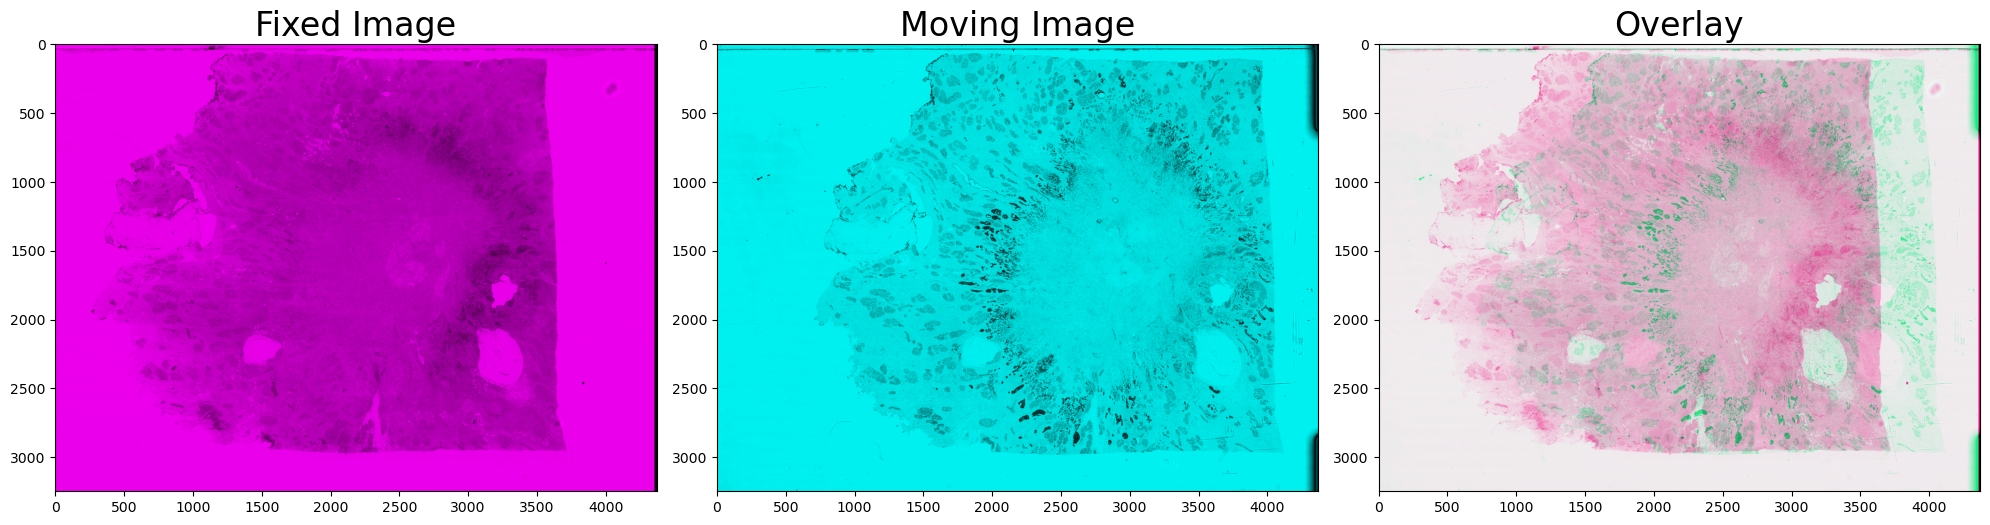

In [4]:

fixed_slice = np.asarray(Normalize()(itk.GetArrayFromImage(fixed_image).astype(np.float32)), dtype=np.float32)
moving_slice = np.asarray(Normalize()(itk.GetArrayFromImage(moving_image).astype(np.float32)), dtype=np.float32)

fixed_color = np.zeros((fixed_slice.shape[0], fixed_slice.shape[1], 3), dtype=np.float32)
fixed_color[:, :, 0] = fixed_slice
fixed_color[:, :, 2] = fixed_slice  # magenta = red + blue

moving_color = np.zeros((moving_slice.shape[0], moving_slice.shape[1], 3), dtype=np.float32)
moving_color[:, :, 1] = moving_slice
moving_color[:, :, 2] = moving_slice  # cyan = green + blue

before_reg = magenta_cyan_overlay(moving_slice,fixed_slice)

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(fixed_color)
axes[0].set_title('Fixed Image', fontsize=24)

axes[1].imshow(moving_color)
axes[1].set_title('Moving Image', fontsize=24)

axes[2].imshow(before_reg)
axes[2].set_title('Overlay', fontsize=24)

plt.tight_layout()
plt.show()
plt.close(fig)

del fixed_color, moving_color, before_reg

### Coarse pre-alignment for large translations

The gradient-based optimizer behind the `"translation"`/`"rigid"`/`"affine"` parameter maps below has a limited capture range — it follows local gradients of the metric, so a large or uncertain initial displacement (here, close to 400 pixels horizontally) can be missed or even pull it toward the wrong optimum, especially with a lot of background in the images.

For this, do an exhaustive search instead of a gradient descent: elastix's `"FullSearch"` optimizer evaluates every candidate translation on a grid rather than following a gradient, so it can't get stuck in a local optimum. Run it on a heavily downsampled copy of the images (cheap to evaluate many candidates at low resolution) over a wide range, then use the result to pre-align the moving image before the fine multi-stage registration. Widen `search_range_x`/`search_range_y` below if your expected displacement is larger.

In [5]:
from skimage.transform import rescale

downscale = 8
search_range_x = (-800, 800)  # pixels, full resolution
search_range_y = (-200, 200)  # pixels, full resolution
step = 16  # pixels, full resolution

fixed_small = rescale(itk.GetArrayFromImage(fixed_image).astype(np.float32), 1 / downscale, anti_aliasing=True)
moving_small = rescale(itk.GetArrayFromImage(moving_image).astype(np.float32), 1 / downscale, anti_aliasing=True)
fixed_small_image = itk.GetImageFromArray(fixed_small.astype(np.float32))
moving_small_image = itk.GetImageFromArray(moving_small.astype(np.float32))

coarse_params = itk.ParameterObject.GetDefaultParameterMap("translation")
coarse_params["FullSearchSpace0"] = [
    "tx", "0",
    str(search_range_x[0] / downscale), str(search_range_x[1] / downscale), str(step / downscale),
]
coarse_params["FullSearchSpace1"] = [
    "ty", "1",
    str(search_range_y[0] / downscale), str(search_range_y[1] / downscale), str(step / downscale),
]

_, coarse_transform_parameters = itk.elastix_registration_method(
    fixed_small_image, moving_small_image, 
    parameter_object=itk.ParameterObject.New(parameter_map=coarse_params), 
    log_to_console=False
)
coarse_tx = float(coarse_transform_parameters.GetParameterMap(0)["TransformParameters"][0]) * downscale
coarse_ty = float(coarse_transform_parameters.GetParameterMap(0)["TransformParameters"][1]) * downscale
print(f"Coarse translation found: ({coarse_tx:.0f}, {coarse_ty:.0f}) pixels")

Coarse translation found: (398, 13) pixels


In [6]:
moving_image_before_shift=np.asarray(Normalize()(itk.GetArrayFromImage(moving_image).astype(np.float32)), dtype=np.float32)
moving_image = shift_image(moving_image, coarse_tx, coarse_ty)

### Registration

A single affine stage starting from identity can get stuck in a bad local optimum when the moving image is rotated by a large angle relative to the fixed image — it has to find the right rotation, scale, shear, and translation all at once, from the same starting guess. Chaining `"translation"` → `"rigid"` → `"affine"` stages avoids this: each stage narrows down its (few) parameters first and hands the result to the next stage as its starting point, so the final affine step only has to fine-tune a transform that's already close to correct.

In [7]:
#translation_parameter_map = itk.ParameterObject.GetDefaultParameterMap("translation")
rigid_parameter_map = itk.ParameterObject.GetDefaultParameterMap("rigid")
affine_parameter_map = itk.ParameterObject.GetDefaultParameterMap("affine")

parameter_object = itk.ParameterObject.New()
#parameter_object.AddParameterMap(translation_parameter_map)
parameter_object.AddParameterMap(rigid_parameter_map)
parameter_object.AddParameterMap(affine_parameter_map)

In [8]:
# Call registration function
result_image, result_transform_parameters = itk.elastix_registration_method(
    fixed_image, moving_image, parameter_object=parameter_object, log_to_console=False
)

In [9]:
#Saving the registered image
#output_dir = Path("output")
#output_dir.mkdir(exist_ok=True)
#itk.imwrite(result_image, output_dir / "RegisteredImage.tif")

### Visualization

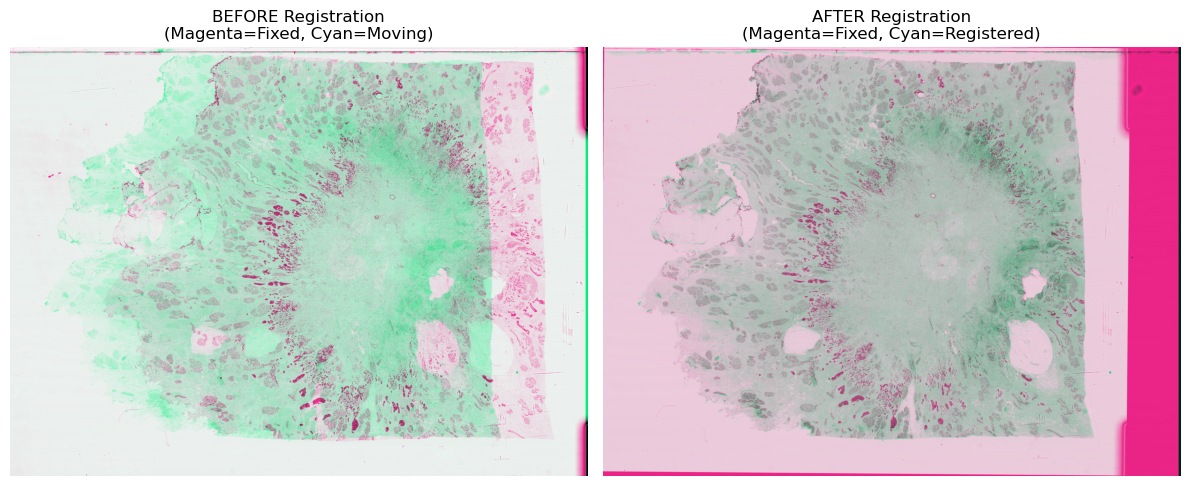

In [10]:

# Visualization
# Convert to array
fixed_arr = itk.GetArrayFromImage(fixed_image).astype(np.float32)
moving_arr = itk.GetArrayFromImage(moving_image).astype(np.float32)
registered_arr = itk.GetArrayFromImage(result_image).astype(np.float32)


fixed_slice = np.asarray(Normalize()(fixed_arr), dtype=np.float32)
moving_slice = np.asarray(Normalize()(moving_arr), dtype=np.float32)
registered_slice = np.asarray(Normalize()(registered_arr), dtype=np.float32)


# Magenta = Fixed, Cyan = Moving/Registered; agreement reads as gray instead of yellow
overlay_before = magenta_cyan_overlay(fixed_slice,moving_image_before_shift )
overlay_after = magenta_cyan_overlay(fixed_slice,registered_slice )

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_before)
axes[0].set_title('BEFORE Registration\n(Magenta=Fixed, Cyan=Moving)')
axes[0].axis('off')

axes[1].imshow(overlay_after)
axes[1].set_title('AFTER Registration\n(Magenta=Fixed, Cyan=Registered)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
plt.close(fig)
del overlay_before, overlay_after

### Quantitative comparison

Visual checks are useful but subjective. Normalized cross-correlation (NCC) — equivalent to the Pearson correlation coefficient, computed here with `numpy.corrcoef` — gives a single number summarizing how well the fixed and moving/registered images agree, so improvement from registration doesn't have to be judged by eye alone.

Caveat for this specific H&E/PGR pair: elastix optimizes mutual information, not correlation, and the two stains don't have a linear intensity relationship (dark PGR-positive regions vs. dark hematoxylin nuclei don't correspond to the same tissue). NCC can therefore stay low or even disagree with a genuinely better alignment here — treat the checkerboard/overlay plots as the primary check for this dataset, and NCC as a rough secondary signal.

In [11]:
ncc_before = np.corrcoef(fixed_arr.flatten(), moving_image_before_shift.flatten())[0, 1]
ncc_after = np.corrcoef(fixed_arr.flatten(), registered_arr.flatten())[0, 1]

print(f"Normalized cross-correlation BEFORE registration: {ncc_before:.3f}")
print(f"Normalized cross-correlation AFTER registration:  {ncc_after:.3f}")

Normalized cross-correlation BEFORE registration: 0.263
Normalized cross-correlation AFTER registration:  -0.033


A default set of registration parameters are available for

* translation
* rigid
* affine
* bspline
* spline
* groupwise

### Understanding the parameters

In [12]:
# Get number of transforms (one per chained registration stage)
num_transforms = result_transform_parameters.GetNumberOfParameterMaps()
print(f"Number of parameter maps: {num_transforms}")

# Print the parameters for every stage, in the order they were applied
for i in range(num_transforms):
    param_map = result_transform_parameters.GetParameterMap(i)
    print(f"\nStage {i}: {param_map['Transform'][0]}")
    for key in param_map:
        print(f"  {key}: {param_map[key]}")

Number of parameter maps: 2

Stage 0: EulerTransform
  CenterOfRotationPoint: ('2184.5', '1623.5')
  CompressResultImage: ('false',)
  DefaultPixelValue: ('0',)
  Direction: ('1', '0', '0', '1')
  FinalBSplineInterpolationOrder: ('3',)
  FixedImageDimension: ('2',)
  FixedInternalImagePixelType: ('float',)
  HowToCombineTransforms: ('Compose',)
  Index: ('0', '0')
  InitialTransformParameterFileName: ('NoInitialTransform',)
  MovingImageDimension: ('2',)
  MovingInternalImagePixelType: ('float',)
  NumberOfParameters: ('3',)
  Origin: ('0', '0')
  ResampleInterpolator: ('FinalBSplineInterpolator',)
  Resampler: ('DefaultResampler',)
  ResultImageFormat: ('nii',)
  ResultImagePixelType: ('float32',)
  Size: ('4370', '3248')
  Spacing: ('1', '1')
  Transform: ('EulerTransform',)
  TransformParameters: ('-0.0085832966843084', '0.8337763325164775', '0.5486778549822509')
  UseDirectionCosines: ('true',)

Stage 1: AffineTransform
  CenterOfRotationPoint: ('2185.3337763325167', '1624.04867785

### Trying other parameter maps

For comparison, run the *single-stage* `"rigid"` and `"bspline"` default maps (starting from identity, unlike the chained pipeline above) against the chained translation→rigid→affine result. To keep the search itself cheap on these large images, run it on a downsampled copy — but the found transform is expressed in *physical units*, not pixels, so rather than rescaling its (possibly many, for bspline) numeric parameters by hand, just tell `transformix` that the full-resolution moving image is `downscale` times finer (covers the same physical extent with `downscale` times more pixels) by setting its `Spacing` to `1/downscale`. It then resamples the real, full-detail image straight into a full-resolution result, so every panel below is shown at the same real resolution as the chained-affine result — including a zoomed-in crop, since a 4000+ pixel-wide figure can't show fine detail on its own.

The default `"bspline"` map's control-point grid is also very fine relative to these images (`FinalGridSpacingInPhysicalUnits=10`, i.e. a control point roughly every 10 pixels on the downsampled copy), which lets it warp so locally that it fits noise rather than real structure. Widening the grid spacing to 40 cuts the number of control points by ~10x and keeps the deformation smooth and plausible instead of extreme.

In [13]:
# Downsample the *current* (already coarse-shifted) images fresh, so this
# comparison starts from the same aligned baseline as the chained pipeline.
cmp_fixed_small = rescale(fixed_arr, 1 / downscale, anti_aliasing=True).astype(np.float32)
cmp_moving_small = rescale(moving_arr, 1 / downscale, anti_aliasing=True).astype(np.float32)
cmp_fixed_small_image = itk.GetImageFromArray(cmp_fixed_small)
cmp_moving_small_image = itk.GetImageFromArray(cmp_moving_small)

comparison_results = {}

for name in ["rigid", "bspline"]:
    pm = itk.ParameterObject.GetDefaultParameterMap(name)
    if name == "bspline":
        pm["FinalGridSpacingInPhysicalUnits"] = ["40.0"]  # coarser grid -> less extreme local warping
    po = itk.ParameterObject.New(parameter_map=pm)
    res_img, res_tp = itk.elastix_registration_method(
        cmp_fixed_small_image, cmp_moving_small_image, parameter_object=po, log_to_console=False
    )
    ncc = np.corrcoef(cmp_fixed_small.flatten(), itk.GetArrayFromImage(res_img).astype(np.float32).flatten())[0, 1]

    # The transform above was found at 1/downscale resolution but is expressed
    # in physical units, not pixels, so its numeric parameters don't need any
    # rescaling -- just tell transformix that the full-resolution moving image
    # covers the same physical extent with `downscale` times more pixels.
    high_res_map = dict(res_tp.GetParameterMap(0))
    high_res_map["Size"] = [str(fixed_slice.shape[1]), str(fixed_slice.shape[0])]
    high_res_map["Spacing"] = [str(1 / downscale), str(1 / downscale)]
    high_res_tp = itk.ParameterObject.New()
    high_res_tp.AddParameterMap(high_res_map)

    moving_image_fine = itk.GetImageFromArray(moving_arr)
    moving_image_fine.SetSpacing([1 / downscale, 1 / downscale])

    res_full = itk.transformix_filter(moving_image_fine, transform_parameter_object=high_res_tp)
    res_full_arr = itk.GetArrayFromImage(res_full).astype(np.float32)

    comparison_results[name] = {
        "image": np.asarray(Normalize()(res_full_arr), dtype=np.float32),
        "ncc": ncc,
        "hrtp": high_res_tp
    }
    del res_img, res_tp, po, pm, high_res_map, high_res_tp, moving_image_fine, res_full, res_full_arr

comparison_results["chained affine"] = {"image": registered_slice, "ncc": ncc_after,"hrtp": result_transform_parameters}
#del cmp_fixed_small, cmp_moving_small, cmp_fixed_small_image, cmp_moving_small_image

rigid            NCC: -0.038
bspline          NCC: -0.080
chained affine   NCC: -0.033


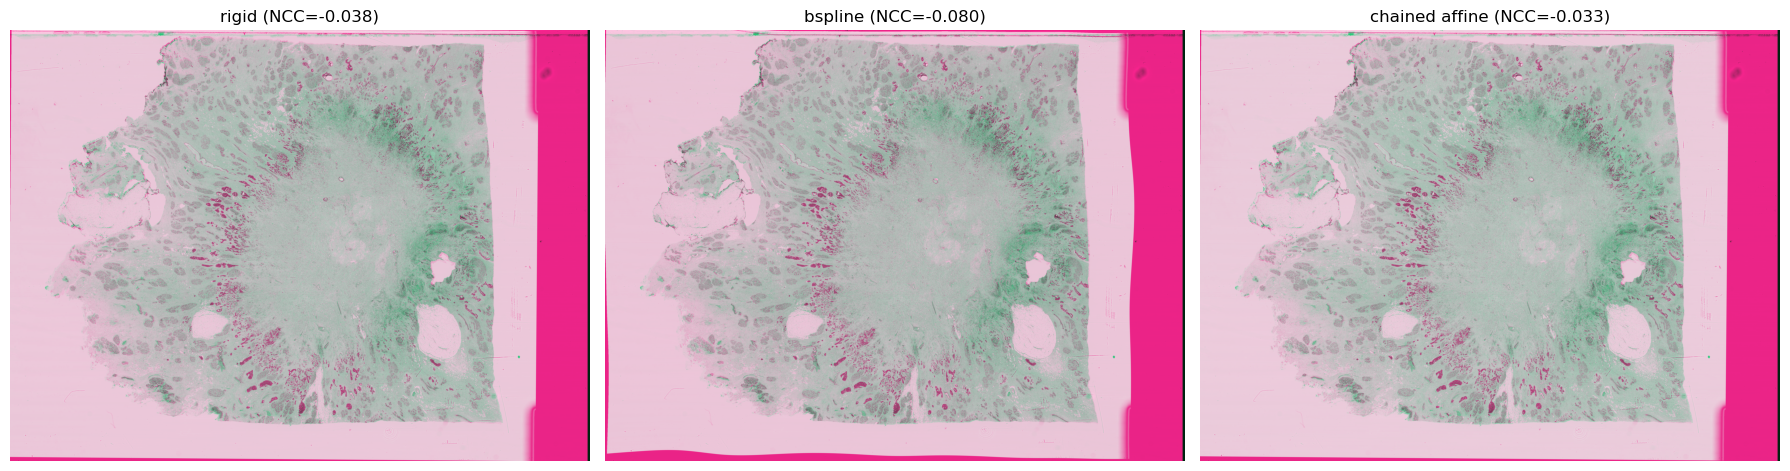

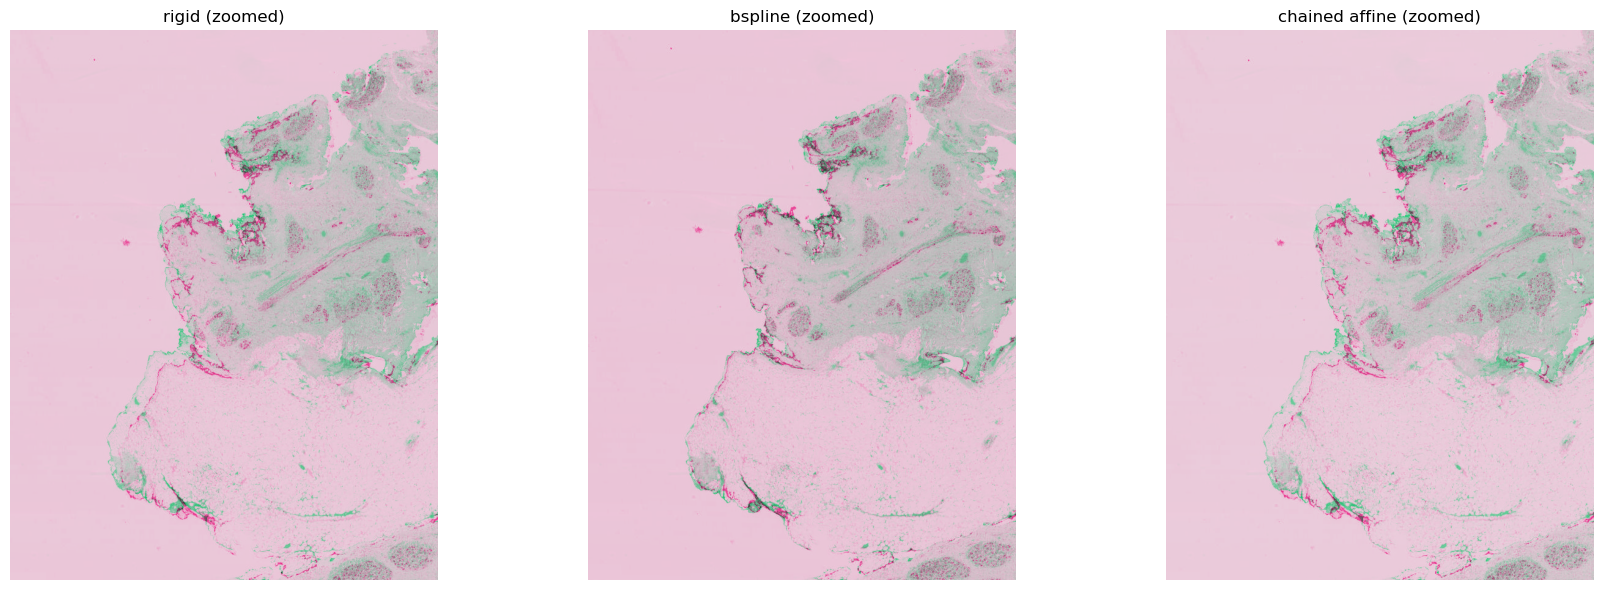

In [14]:

for name, r in comparison_results.items():
    print(f"{name:16s} NCC: {r['ncc']:.3f}")

fig, axes = plt.subplots(1, len(comparison_results), figsize=(6 * len(comparison_results), 6))
for ax, (name, r) in zip(axes, comparison_results.items()):
    overlay = magenta_cyan_overlay(fixed_slice, r["image"])
    ax.imshow(overlay)
    ax.set_title(f"{name} (NCC={r['ncc']:.3f})")
    ax.axis('off')
plt.tight_layout()
plt.show()
plt.close(fig)

# Zoomed-in crop -- same region cut out of every panel, now that all three
# are genuinely at the same full resolution -- to see fine detail a
# 4000+ pixel-wide figure can't show.
zoom_rows = slice(700, 1600)
zoom_cols = slice(200, 900)
fig, axes = plt.subplots(1, len(comparison_results), figsize=(6 * len(comparison_results), 6))
for ax, (name, r) in zip(axes, comparison_results.items()):
    overlay = magenta_cyan_overlay(fixed_slice, r["image"])
    ax.imshow(overlay[zoom_rows, zoom_cols])
    ax.set_title(f"{name} (zoomed)")
    ax.axis('off')
plt.tight_layout()
plt.show()
plt.close(fig)
#del comparison_results

### Applying the transform to another image

You register once, but often need to warp more than the single (grayscale) image actually used for registration — here, the original full-color photographs. `itk.transformix_filter` applies an already-computed transform (`result_transform_parameters`) to any image on the moving image's grid, without re-running registration.

`transformix` only accepts scalar images, though, so an RGB image has to be split into its three channels, each warped separately, and recombined — the same trick as warping a multi-channel fluorescence image or a labeled segmentation stored as one-hot channels.

Whichever transform is applied here has to be matched with the spacing it declares its input as living in — read it straight from the transform's own parameter map (`Spacing`) instead of hardcoding it, since it differs between `result_transform_parameters` (found directly at full resolution, spacing 1) and the `"rigid"`/`"bspline"` comparison's `hrtp` (found on a downsampled copy and rescaled to full resolution, spacing `1/downscale`) — get this wrong and you're back to the "huge zoom" bug from before.

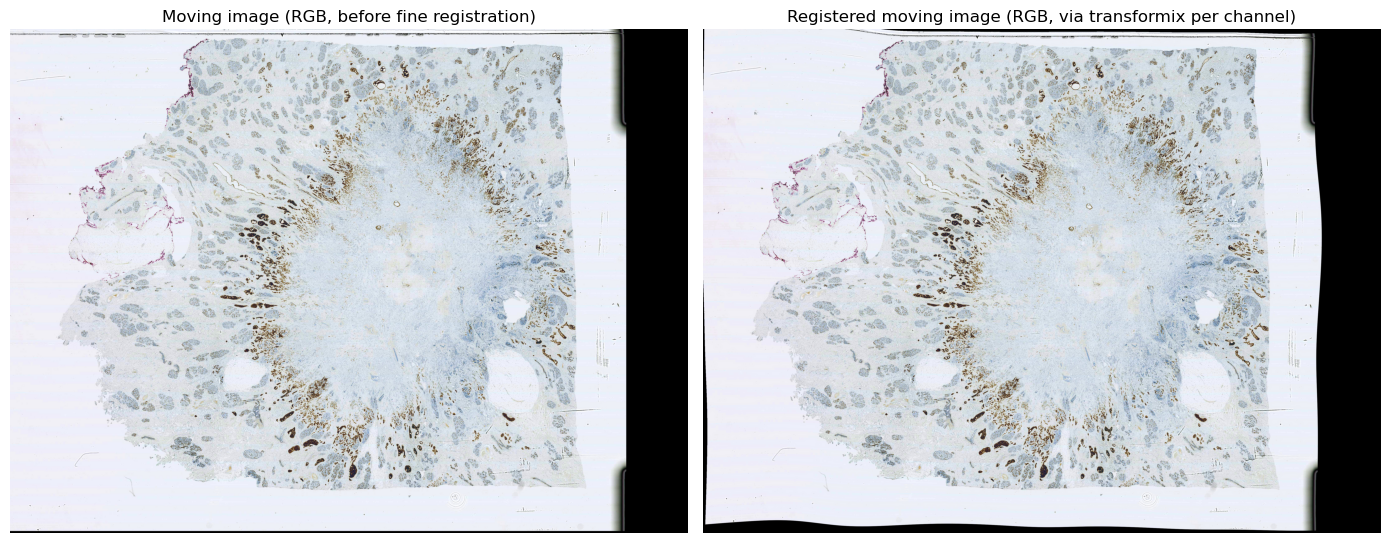

In [25]:
# Read the original color photographs -- registration itself ran on the
# grayscale versions, but there's no reason the *result* has to be grayscale.
fixed_rgb = read_rgb(data_dir / "18_HE_val_level3.jpg")
moving_rgb = read_rgb(data_dir / "18_PGR_val_level3-2.jpg")

target_shape = itk.GetArrayFromImage(fixed_image).shape  # (height, width) the registration actually ran on

transformation_name="bspline"

transform_to_apply = comparison_results[transformation_name]["hrtp"]
input_spacing = float(transform_to_apply.GetParameterMap(0)["Spacing"][0])  # must match this transform's own declared input spacing

prealigned_channels = []
registered_channels = []
for channel in range(3):
    # Match what happened to the grayscale moving image: pad to the shared
    # canvas, then apply the same coarse pre-shift, before warping with the
    # transform elastix actually found.
    channel_image = shift_image(
        rgb_channel_to_padded_image(moving_rgb, channel, target_shape, spacing=input_spacing),
        coarse_tx, coarse_ty,
    )
    prealigned_channels.append(itk.GetArrayFromImage(channel_image))

    warped = itk.transformix_filter(channel_image, transform_parameter_object=transform_to_apply)
    registered_channels.append(itk.GetArrayFromImage(warped))
    del channel_image, warped

fixed_rgb_padded = np.stack(
    [itk.GetArrayFromImage(rgb_channel_to_padded_image(fixed_rgb, c, target_shape)) for c in range(3)], axis=-1
)
moving_rgb_before = np.stack(prealigned_channels, axis=-1)
moving_rgb_registered = np.stack(registered_channels, axis=-1)
del fixed_rgb, moving_rgb, prealigned_channels, registered_channels

# Visualize!

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(np.clip(moving_rgb_before, 0, 255).astype(np.uint8))
axes[0].set_title('Moving image (RGB, before fine registration)')
axes[0].axis('off')

axes[1].imshow(np.clip(moving_rgb_registered, 0, 255).astype(np.uint8))
axes[1].set_title('Registered moving image (RGB, via transformix per channel)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
plt.close(fig)

### Checkerboard comparison

Color overlays are intuitive but can hide small local misalignments. A checkerboard blend — alternating tiles from each image — makes it easier to spot where edges line up (or don't) across tile boundaries. Shown here with the original color images, now that the previous cell has produced a registered RGB version.

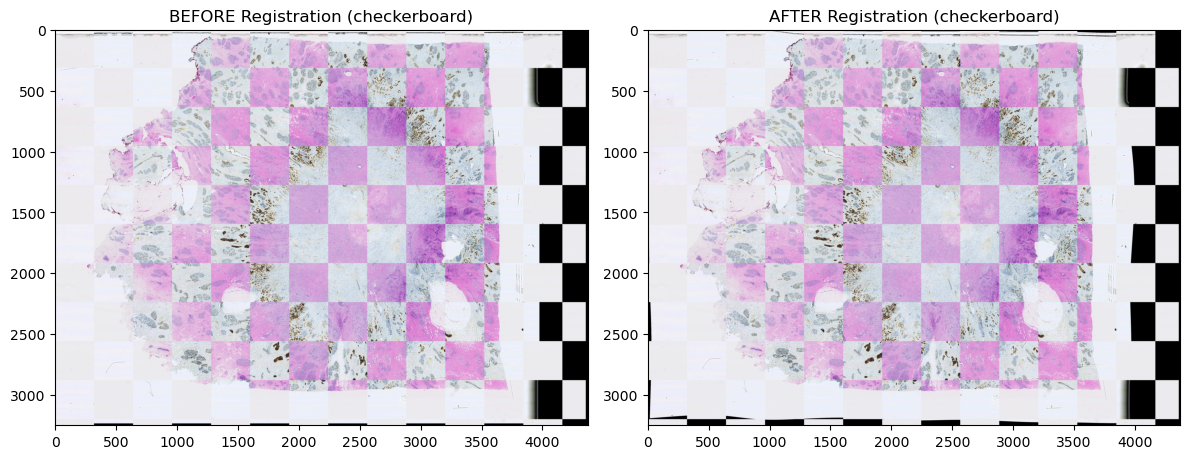

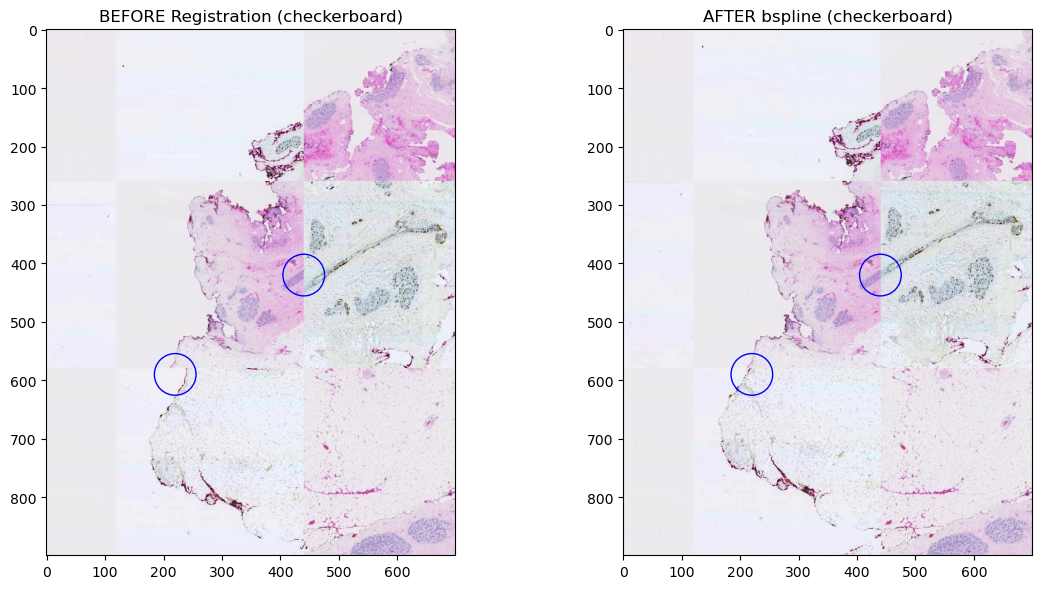

In [26]:
checker_before = checkerboard(fixed_rgb_padded, moving_rgb_before,tile=320)
# checker_after = checkerboard(fixed_rgb_padded, comparison_results["bspline"]["image"],tile=320)
checker_after = checkerboard(fixed_rgb_padded, moving_rgb_registered,tile=320)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(np.clip(checker_before, 0, 255).astype(np.uint8))
axes[0].set_title('BEFORE Registration (checkerboard)')

axes[1].imshow(np.clip(checker_after, 0, 255).astype(np.uint8))
axes[1].set_title('AFTER Registration (checkerboard)')

plt.tight_layout()
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

mx,my=[220,440],[590,420]
s=900

axes[0].imshow(np.clip(checker_before, 0, 255).astype(np.uint8)[zoom_rows, zoom_cols])
axes[0].set_title('BEFORE Registration (checkerboard)')
#axes[0].set_xlim()

axes[0].scatter(mx,my,marker="o",s=s, facecolors='none',edgecolors='blue',linewidths=1)

axes[1].imshow(np.clip(checker_after, 0, 255).astype(np.uint8)[zoom_rows, zoom_cols])
axes[1].set_title(f'AFTER {transformation_name} (checkerboard)')
axes[1].scatter(mx,my,marker="o",s=s, facecolors='none',edgecolors='blue',linewidths=1)

#axes[1].set_xlim()

plt.tight_layout()
plt.show()
plt.close(fig)
#del checker_before, checker_after, fixed_rgb_padded, moving_rgb_before, moving_rgb_registered